# HF TDOA Analysis - Figures 13 & 14

This notebook uses the `hf_tdoa_lib` library to analyze HF TDOA measurements and generate Figures 13 and 14.

In [1]:
import os
import datetime
import importlib
import hf_tdoa_lib as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Load WAV Files & Find Chirps

In [2]:
base_dir   = 'data'
data_set   = 'TX_WA5FRF_EL09nn-RX_N6RFM_EM12jw-0407KM-40m'
sweep_rate = 10  # Hz/ms

# Path to chirp template - used for finding chirp locations via cross-correlation
template   = os.path.join('templates', 'N6RFM_10Hz_per_ms_template.wav')

data_dir   = os.path.join(base_dir, data_set)
wavlist    = tdoa.obtain_wav_list(data_dir)

In [3]:
# Correlate each WAV with a known template chirp to identify chirp locations in each WAV file.
chirps = tdoa.find_chirps(wavlist, template, sweep_rate=sweep_rate, plot_correlation=False)

## Find TDOAs

In [4]:
debug_TDOAs = False

tdoa_dct = {}

### 1F2-2F2
tdoa_dct['1F2-2F2']  = dct = {}
dct['filter_limts']  = [10,50]          # Bandpass filter limits [Hz]
dct['search_limits'] = [-0.1,0.1,11,20] # (start_offset, end_offset, min_freq, max_freq)
dct['model_coeffs']  = (140.2,48.3)     # (slope,intercept) for layer height model
dct['linestyle']     = '--'
dct['linewidth']     = 3
dct['color']         = 'tab:green'
dct['marker']        = 'o'

### 1F2-1E
tdoa_dct['1F2-1E']   = dct = {}
dct['filter_limts']  = [2.5,30]        # Bandpass filter limits [Hz]
dct['search_limits'] = [-0.1,0.1,5,12] # (start_offset, end_offset, min_freq, max_freq)
dct['model_coeffs']  = (181.8,135.5)   # (slope,intercept) for layer height model
dct['linestyle']     = '-.'
dct['linewidth']     = 1.5
dct['color']         = 'tab:blue'
dct['marker']        = '*'

### 2F2-1E
tdoa_dct['2F2-1E'] = dct = {}
dct['filter_limts']  = [20,30]          # Bandpass filter limits [Hz]
dct['search_limits'] = [-0.1,0.1,22,30] # (start_offset, end_offset, min_freq, max_freq)
dct['model_coeffs']  = (79.4,85.6)      # (slope,intercept) for layer height model
dct['linestyle']     = ':'
dct['linewidth']     = 2.5
dct['color']         = 'tab:orange'
dct['marker']        = '^'

for set_name, params in tdoa_dct.items():
    filter_limts  = params['filter_limts']
    search_limits = params['search_limits']
    chirps        = tdoa.find_TDOAs(chirps, search_limits, filter_limts, set_name=set_name,
                                   plot_fft=debug_TDOAs, only_one=debug_TDOAs)

/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/fig_11_12/hf_tdoa_lib.py:489: RuntimeWarning: Mean of empty slice
  mean_beats.append(np.nanmean(beat_arr))


## Figure 13 - TDOA Measurements

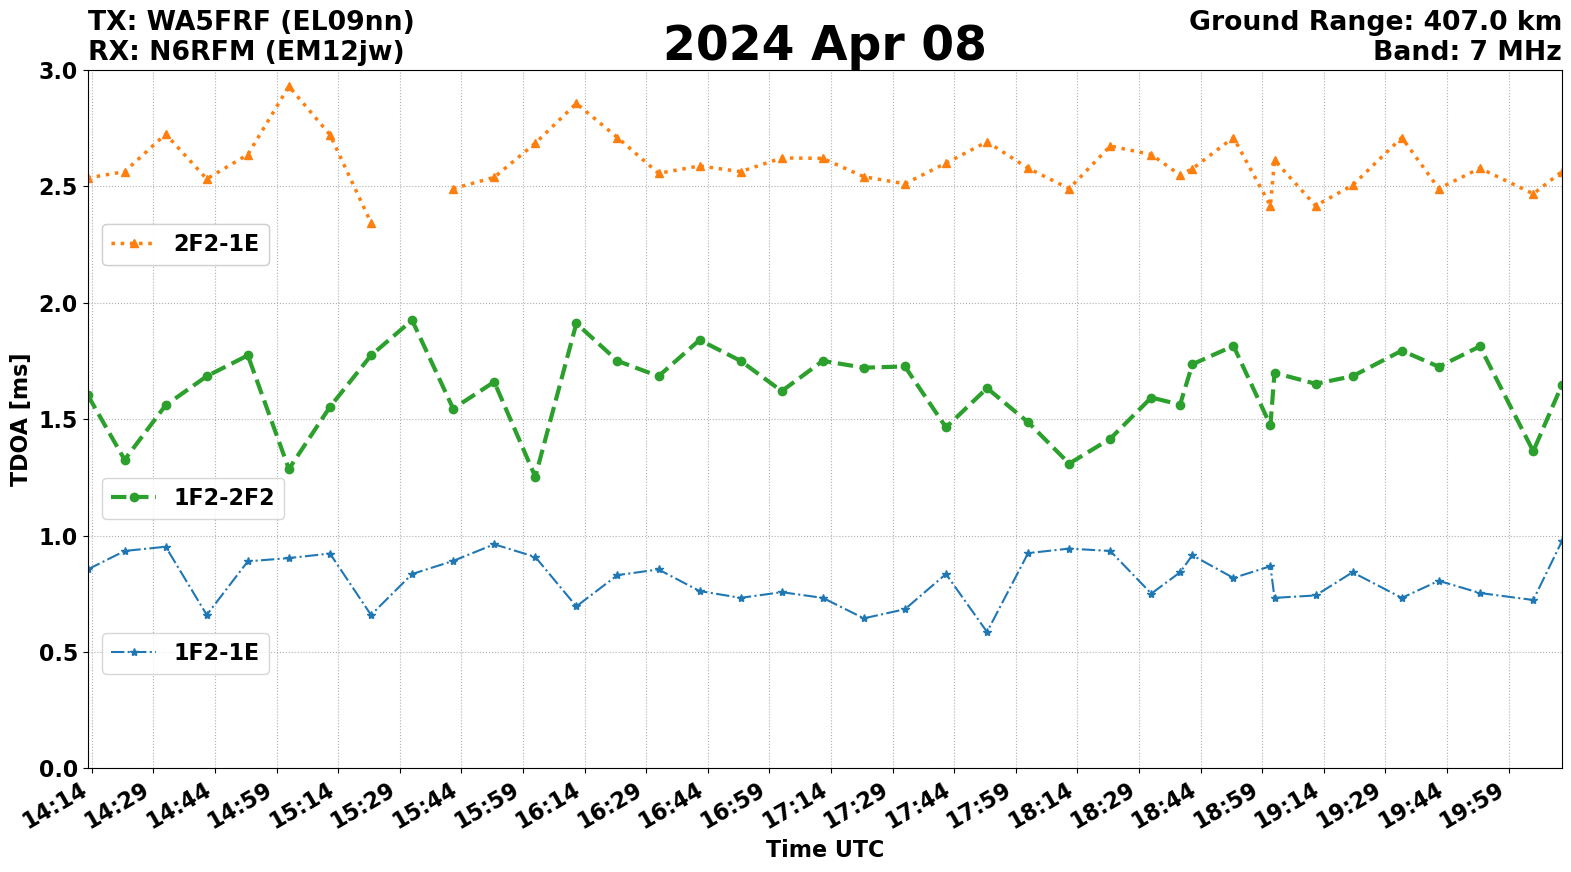

In [5]:
tdoa.plot_TDOAs(chirps, tdoa_dct)

## Figure 14 - Layer Heights Comparison with Ionosonde

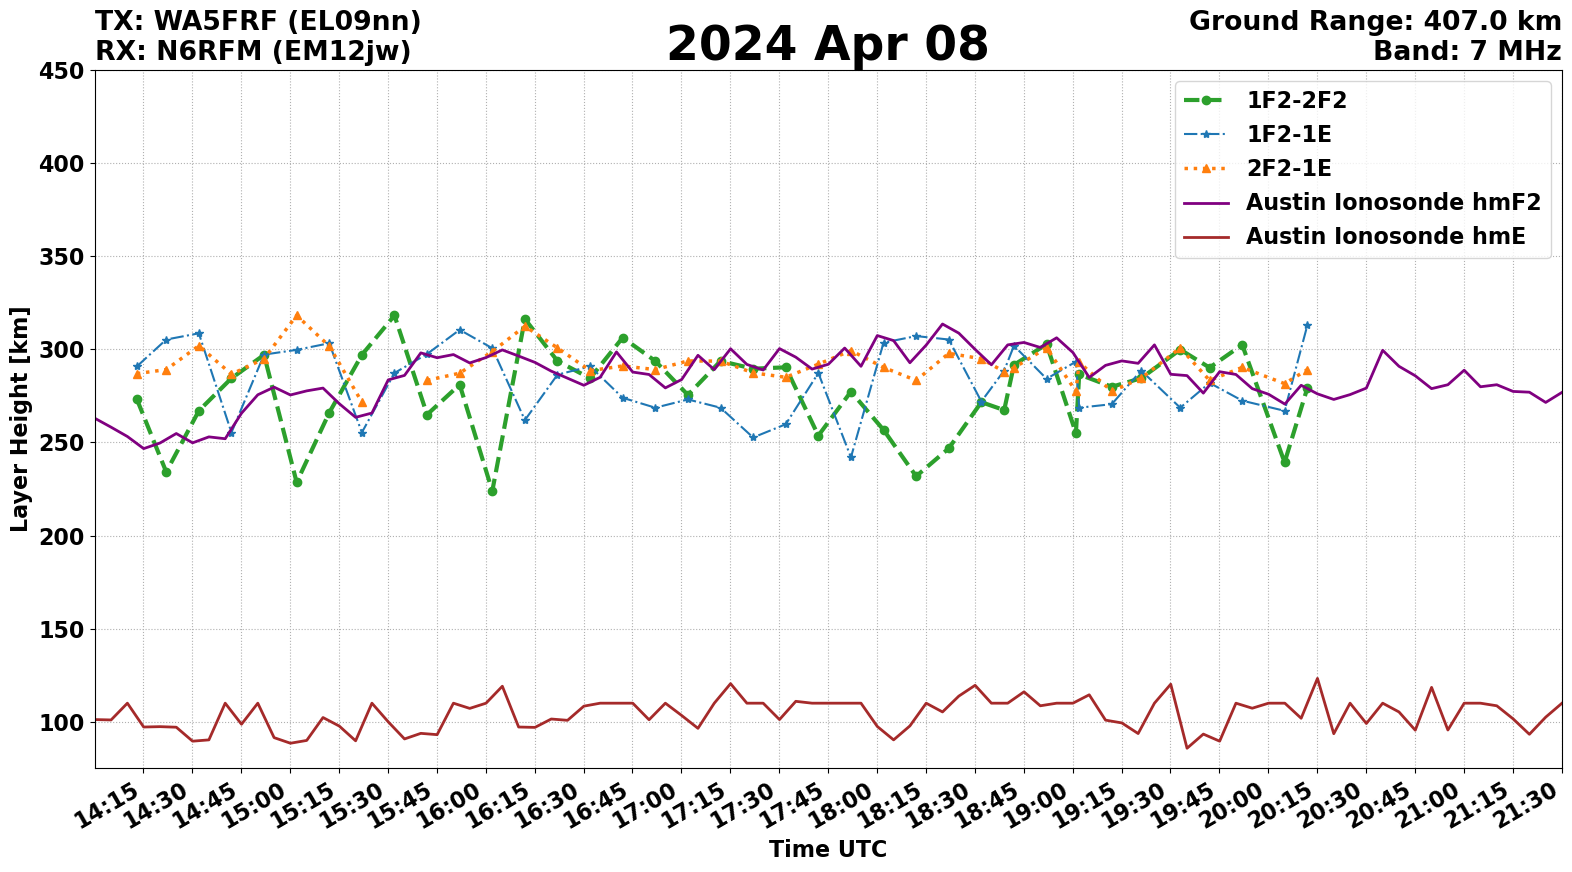

In [6]:
tdoa.plot_hmf2(chirps, tdoa_dct)